<a href="https://colab.research.google.com/github/soumilimahindar-Asure/Machine-Learning/blob/main/AIML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressu

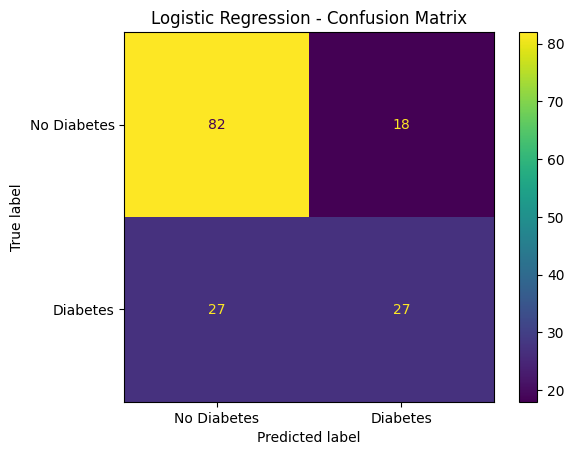


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


ROC-AUC Score: 0.8130


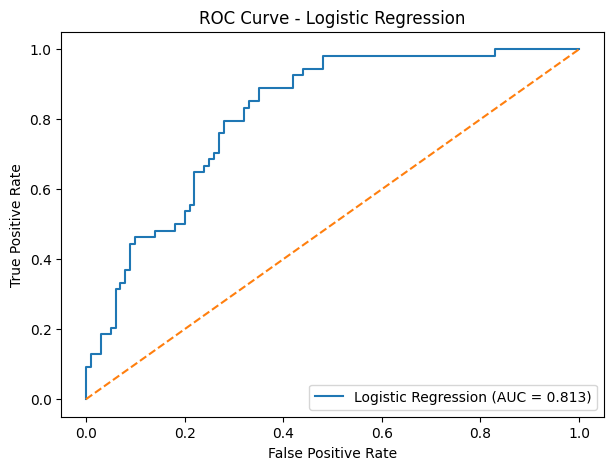


Model Coefficients:
                    Feature  Coefficient  Odds_Ratio
1                   Glucose     1.182511    3.262558
5                       BMI     0.688735    1.991194
0               Pregnancies     0.377502    1.458637
6  DiabetesPedigreeFunction     0.233386    1.262869
7                       Age     0.147798    1.159279
4                   Insulin    -0.066157    0.935983
2             BloodPressure    -0.044066    0.956891
3             SkinThickness     0.028225    1.028627


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
df = pd.read_csv("diabetes_dataset.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]
df.columns = columns
print("\nColumn Names:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nZero Values:")
print((df == 0).sum())
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df[zero_columns] = df[zero_columns].replace(0, np.nan)
df[zero_columns] = df[zero_columns].fillna(
    df[zero_columns].median()
)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("\nModel trained successfully.")
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy: {:.2f}%".format(accuracy * 100))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score: {:.4f}".format(roc_auc))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label="Logistic Regression (AUC = {:.3f})".format(roc_auc)
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})
coef_df["Odds_Ratio"] = np.exp(coefficients)
coef_df["Absolute_Coefficient"] = abs(coefficients)
coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)
print("\nModel Coefficients:")
print(
    coef_df[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ]
)